# Unsupervised Learning for Database Segmentation

This notebook demonstrates the application of clustering algorithms for database segmentation. We will explore a public dataset, preprocess the data, train the model, evaluate the results based on a (labeled) validation dataset, and derive insights for the whole.

Made by Leticia Barbanera Menezes (14588642) and João Rissi Magnani (nusp)

## Introduction

This notebook aims to explore data clustering methods applied to the public database of **Severe Acute Respiratory Syndrome (SARS)** from the Brazilian Unified Health System (SUS), made available through Sivep-Gripe, the official system for registering SARS cases and deaths in Brazil. The database has national coverage, geographic granularity by municipality, temporal granularity by day, and gathers records organized by epidemiological year.

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-dark.mplstyle')
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

## Dataset Description & Exploratory Analysis

### Dataset Description

In this application, was selected for a specific set of attributes: notification date (DT_NOTIFIC), sex (CS_SEXO), age (NU_IDADE_N), race/color (CS_RACA), state of residence (SG_UF), geographic zone (CS_ZONA), comorbidities and risk factors such as diabetes, heart disease, obesity and immunosuppression, as well as symptoms such as fever, cough, sore throat, dyspnea, respiratory discomfort, O2 saturation below 95%, diarrhea, vomiting, abdominal pain, fatigue, loss of smell and loss of taste.


## Data Preprocessing

### Steps

1. **Handling Missing Values:** Check and impute or drop missing values. (Our synthetic data does not have missing values.)
2. **Feature Engineering:** Creating (possibly) more meaningful features from the original ones.
3. **Feature Scaling:** Standardize features to bring them to the same scale. This is important for distance-based algorithms like K-Means.
4. **Feature Encoding:** Transforming text-based features into numerical representations so ML algorithms can better explore it.
5. **Dimensionality Reduction:** In cases of high-dimensional data, techniques like PCA may be applied. 


In [2]:
df = pd.read_parquet("df_data_full.parquet")

In [3]:
df_guide = pd.read_parquet ("df_data_val.parquet")

In [4]:
print(df_guide['CLUSTER_DETAILS'].unique())

['OUTRO_VIRUS_CURA' 'COVID19_CURA' 'SRAG_NAO_ESPEC_CURA' 'COVID19_OBITO'
 'SRAG_NAO_ESPEC_OBITO' 'INFLUENZA_CURA' 'OUTRO_AGENTE_CURA'
 'OUTRO_VIRUS_OBITO' 'OUTRO_AGENTE_OBITO' 'INFLUENZA_OBITO']


In [5]:
cluster_mapping = {
    'OUTRO_VIRUS_CURA': 0,
    'COVID19_CURA': 1,
    'SRAG_NAO_ESPEC_CURA': 2,
    'COVID19_OBITO': 3,
    'SRAG_NAO_ESPEC_OBITO': 4,
    'INFLUENZA_CURA': 5,
    'OUTRO_AGENTE_CURA': 6,
    'OUTRO_VIRUS_OBITO': 7,
    'OUTRO_AGENTE_OBITO': 8,
    'INFLUENZA_OBITO': 9}

#if data's correct then this step should be essentially dumb, and we're just changing the same numbers for the same other numbers everytime
df_guide['CLUSTER_BIN'] = df_guide['CLUSTER_DETAILS'].map(cluster_mapping)
df_guide = df_guide.drop(columns=['CLUSTER_DETAILS'])
df_guide['CLUSTER_BIN'] = df_guide['CLUSTER_BIN'].astype(int)

In [6]:
df_guide.columns

Index(['DT_NOTIFIC', 'CS_SEXO', 'NU_IDADE_N', 'CS_RACA', 'SG_UF', 'CS_ZONA',
       'DIABETES', 'CARDIOPATI', 'OBESIDADE', 'IMUNODEPRE', 'FEBRE', 'TOSSE',
       'GARGANTA', 'DISPNEIA', 'DESC_RESP', 'SATURACAO', 'DIARREIA', 'VOMITO',
       'DOR_ABD', 'FADIGA', 'PERD_OLFT', 'PERD_PALA', 'VACINA_COV', 'VACINA',
       'CLUSTER_BIN'],
      dtype='object')

In [7]:
df.head(5)

,DT_NOTIFIC,CS_SEXO,NU_IDADE_N,CS_RACA,SG_UF,CS_ZONA,DIABETES,CARDIOPATI,OBESIDADE,IMUNODEPRE,...,DESC_RESP,SATURACAO,DIARREIA,VOMITO,DOR_ABD,FADIGA,PERD_OLFT,PERD_PALA,VACINA_COV,VACINA
0,2021-06-11,NaN,49,1.0,SP,1.0,NaN,NaN,NaN,NaN,...,1.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-04-26,NaN,57,4.0,PA,1.0,NaN,NaN,NaN,NaN,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
2,2021-03-07,NaN,31,1.0,SP,1.0,2.0,2.0,2.0,2.0,...,1.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,NaN,NaN
3,2020-08-31,NaN,84,1.0,SP,1.0,NaN,NaN,NaN,NaN,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN
4,2020-04-07,NaN,64,4.0,AM,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN


A brief exploration shows that the columns related to symptoms follow a pattern: it appears we have 1 and 2 (as binary-type entries) and missing values ​​(NaN).

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3546334 entries, 0 to 3546333
Data columns (total 24 columns):
 #   Column      Dtype  
---  ------      -----  
 0   DT_NOTIFIC  object 
 1   CS_SEXO     float64
 2   NU_IDADE_N  object 
 3   CS_RACA     float64
 4   SG_UF       object 
 5   CS_ZONA     float64
 6   DIABETES    float64
 7   CARDIOPATI  float64
 8   OBESIDADE   float64
 9   IMUNODEPRE  float64
 10  FEBRE       float64
 11  TOSSE       float64
 12  GARGANTA    float64
 13  DISPNEIA    float64
 14  DESC_RESP   float64
 15  SATURACAO   float64
 16  DIARREIA    float64
 17  VOMITO      float64
 18  DOR_ABD     float64
 19  FADIGA      float64
 20  PERD_OLFT   float64
 21  PERD_PALA   float64
 22  VACINA_COV  float64
 23  VACINA      float64
dtypes: float64(21), object(3)
memory usage: 649.4+ MB


Let's transform the data into the expected types

In [9]:
df["DT_NOTIFIC"] = pd.to_datetime(df["DT_NOTIFIC"], errors="coerce", dayfirst=True)
df["SG_UF"] = df["SG_UF"].astype("string").str.strip().astype("category")
df["CS_ZONA"] = df["CS_ZONA"].astype("category")
df['NU_IDADE_N']= df['NU_IDADE_N'].astype('float')
df["CS_SEXO"] = df["CS_SEXO"].apply(lambda x: 1 if x == 1 else 0)
df["CS_RACA"] = df["CS_RACA"].astype("Int64")
df["NU_IDADE_N"] = pd.to_numeric(df["NU_IDADE_N"], errors="coerce").astype("Int64")

### Handling Missing Values

In [10]:
print(len(df))

3546334


In [11]:
print(df.isnull().sum())

DT_NOTIFIC    2166386
CS_SEXO             0
NU_IDADE_N          0
CS_RACA        583319
SG_UF             635
CS_ZONA        371565
DIABETES      2064663
CARDIOPATI    1957566
OBESIDADE     2258519
IMUNODEPRE    2277030
FEBRE          557721
TOSSE          420127
GARGANTA      1026486
DISPNEIA       447489
DESC_RESP      634304
SATURACAO      599690
DIARREIA      1044886
VOMITO        1062720
DOR_ABD       1425911
FADIGA        1323756
PERD_OLFT     1438568
PERD_PALA     1442269
VACINA_COV    1522968
VACINA        1990847
dtype: int64


Missing not at random! We will use a three-options flag: yes, no and not informed

In [12]:
cols = [
    "CS_SEXO", "CS_RACA", "DIABETES", "CARDIOPATI", "OBESIDADE",
    "IMUNODEPRE", "FEBRE", "TOSSE", "GARGANTA", "DISPNEIA", "DESC_RESP",
    "SATURACAO", "DIARREIA", "VOMITO", "DOR_ABD", "FADIGA", "PERD_OLFT",
    "PERD_PALA", "VACINA_COV", "VACINA"]
for col in cols:
    # 1 -> 1; 2 -> 0; Nan -> -1
    df[col] = df[col].replace(2, 0)
    df[col] = df[col].fillna(-1).astype(np.int8)

### Feature Engineering + Feature Encoding

In [13]:
df['MES'] = df['DT_NOTIFIC'].dt.month
df['ANO'] = df['DT_NOTIFIC'].dt.year

In [14]:
df['MES'] = np.select(
    [df['MES'].isin([12, 1, 2]), 
     df['MES'].isin([3, 4, 5]), 
     df['MES'].isin([6, 7, 8]), 
     df['MES'].isin([9, 10, 11])], 
    [1, 2, 3, 4], 
    default=0)

In [15]:
min_year = df['ANO'].min()
max_year = df['ANO'].max()

print(f"Year range: {min_year} to {max_year}")

Year range: 2019.0 to 2025.0


In [16]:
df['ANO'] = np.select(
    [(df['ANO'] == 2019), 
    (df['ANO'] >= 2020) & (df['ANO'] <= 2022),
    (df['ANO'] >= 2023) & (df['ANO'] <= 2025)], 
    [1, 2, 3], 
    default=0)

In [17]:
df = df.drop(columns=['DT_NOTIFIC'])

In [18]:
macrorregioes = {
    'AC': 'Norte', 'AL': 'Nordeste', 'AP': 'Norte', 'AM': 'Norte', 'BA': 'Nordeste', 'CE': 'Nordeste',
    'DF': 'Centro-Oeste', 'ES': 'Sudeste', 'GO': 'Centro-Oeste', 'MA': 'Nordeste', 'MT': 'Centro-Oeste',
    'MS': 'Centro-Oeste', 'MG': 'Sudeste', 'PA': 'Norte', 'PB': 'Nordeste', 'PR': 'Sul', 'PE': 'Nordeste',
    'PI': 'Nordeste', 'RJ': 'Sudeste', 'RN': 'Nordeste', 'RS': 'Sul', 'RO': 'Norte', 'RR': 'Norte',
    'SC': 'Sul', 'SP': 'Sudeste', 'SE': 'Nordeste', 'TO': 'Norte'}
df['MACRO_RG'] = df['SG_UF'].map(macrorregioes)
#using higher levels of granularity is better in this context since it results in fewer one hot features

In [19]:
df = df.drop(columns=['SG_UF'])

In [20]:
df = df.drop(columns=['CS_ZONA'])

In [21]:
df['NU_IDADE_N'] = df['NU_IDADE_N'].fillna(-1)
bins = [-np.inf,12,17,39,59,np.inf]
labels = ['CRIANCA','ADOLESCENTE','ADULTO JOVEM','ADULTO','IDOSO']
df['FAIXA_ETARIA'] = pd.cut(df['NU_IDADE_N'],bins=bins,labels=labels)
df = df.drop(columns=['NU_IDADE_N'])

In [22]:
#some features are important cause they're considered comorbidities.
df['idx_comorbidade'] = df[['DIABETES', 'CARDIOPATI', 'OBESIDADE', 'IMUNODEPRE']].clip(lower=0).sum(axis=1)
#since the database's focused on covid, let's build a "score" focused on that
df['score_respiratorio'] = df[['DISPNEIA', 'DESC_RESP', 'SATURACAO']].clip(lower=0).sum(axis=1)

In [23]:
df['missing_density'] = (df[cols] == -1).sum(axis=1)

In [24]:
#encoding of essentially categorical features
df = pd.get_dummies(df, columns=['CS_SEXO'], prefix='sexo', drop_first=True)
#we encode macro_r instead of individual states to avoid overdimensionality issues
df = pd.get_dummies(df, columns=['MACRO_RG'], prefix='regiao', drop_first=True)
#transforms into int8 to save space
new_dummy_cols = [c for c in df.columns if c.startswith(('sexo_', 'regiao_'))]
df[new_dummy_cols] = df[new_dummy_cols].astype(np.int8)

In [25]:
cols_added = [
    'FAIXA_ETARIA', 'idx_comorbidade', 'score_respiratorio', 'missing_density',
    'regiao_Nordeste', 'regiao_Norte', 'regiao_Sudeste', 'regiao_Sul']

for col in cols_added:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(-1).astype(np.int8)

In [26]:
df.columns

Index(['CS_RACA', 'DIABETES', 'CARDIOPATI', 'OBESIDADE', 'IMUNODEPRE', 'FEBRE',
       'TOSSE', 'GARGANTA', 'DISPNEIA', 'DESC_RESP', 'SATURACAO', 'DIARREIA',
       'VOMITO', 'DOR_ABD', 'FADIGA', 'PERD_OLFT', 'PERD_PALA', 'VACINA_COV',
       'VACINA', 'MES', 'ANO', 'FAIXA_ETARIA', 'idx_comorbidade',
       'score_respiratorio', 'missing_density', 'regiao_Nordeste',
       'regiao_Norte', 'regiao_Sudeste', 'regiao_Sul'],
      dtype='object')

In [27]:
features = [col for col in df.columns if col not in ['DT_NOTIFIC', 'SG_UF', 'CS_ZONA', 'FAIXA_ETARIA']]
nulols = df[features].isnull().sum()
print("Colunas com NaN detectadas:")
print(nulols[nulols > 0])
df[features] = df[features].fillna(-1)

Colunas com NaN detectadas:
Series([], dtype: int64)


In [28]:
encoder = OneHotEncoder(sparse_output=False)
df_encoded = encoder.fit_transform(df)

In [29]:
df_encoded = pd.DataFrame(df_encoded, columns=encoder.get_feature_names_out(input_features=df.columns))

In [30]:
df_encoded = df_encoded.drop(columns=['regiao_Nordeste_0', 'regiao_Norte_0', 'regiao_Sudeste_0', 'regiao_Sul_0'])

In [31]:
print(df_encoded.head(5))

   CS_RACA_-1  CS_RACA_0  CS_RACA_1  CS_RACA_3  CS_RACA_4  CS_RACA_5  \
0         0.0        0.0        1.0        0.0        0.0        0.0   
1         0.0        0.0        0.0        0.0        1.0        0.0   
2         0.0        0.0        1.0        0.0        0.0        0.0   
3         0.0        0.0        1.0        0.0        0.0        0.0   
4         0.0        0.0        0.0        0.0        1.0        0.0   

   DIABETES_-1  DIABETES_0  DIABETES_1  CARDIOPATI_-1  ...  \
0          1.0         0.0         0.0            1.0  ...   
1          1.0         0.0         0.0            1.0  ...   
2          0.0         1.0         0.0            0.0  ...   
3          1.0         0.0         0.0            1.0  ...   
4          1.0         0.0         0.0            1.0  ...   

   missing_density_14  missing_density_15  missing_density_16  \
0                 0.0                 0.0                 0.0   
1                 0.0                 0.0                 0.0   

###Extra: Feature Selection

In [32]:
# from sklearn.feature_selection import VarianceThreshold
# #we'll take a look at the data variance within each column and keep only the ones that we consider necessary
# selector = VarianceThreshold(threshold=(.95 * (1 - .95)))
# X_high_variance = selector.fit_transform(df_encoded)

We verify if any column may be removed from the data. This is the case because, with one-hot data, non frequent cats may behave almost as flags while frequent ones control the process. However, it looks like we don't need to drop any features, accordig to this method. Still, we know one-hot results in a redundant column for each original column. Thus, for memory reasons, we could remove the last mapped feature of each. We just won't do it right now for all features.

In [33]:
#this function sums up all pre-processing done to the training set, and applies it appropriately to the validation set, which we call df_guide
def all_preprocessing(df):

  df=df.fillna(-1)

  df["DT_NOTIFIC"] = pd.to_datetime(df["DT_NOTIFIC"], errors="coerce", dayfirst=True)
  df["SG_UF"] = df["SG_UF"].astype("string").str.strip().astype("category")
  df["CS_ZONA"] = df["CS_ZONA"].astype("category")
  df['NU_IDADE_N']= df['NU_IDADE_N'].astype('float')
  df["CS_SEXO"] = df["CS_SEXO"].apply(lambda x: 1 if x == 1 else 0)
  df["CS_RACA"] = df["CS_RACA"].astype("Int64")
  df["NU_IDADE_N"] = pd.to_numeric(df["NU_IDADE_N"], errors="coerce").astype("Int64")

  cols = [
      "CS_SEXO", "CS_RACA", "DIABETES", "CARDIOPATI", "OBESIDADE",
      "IMUNODEPRE", "FEBRE", "TOSSE", "GARGANTA", "DISPNEIA", "DESC_RESP",
      "SATURACAO", "DIARREIA", "VOMITO", "DOR_ABD", "FADIGA", "PERD_OLFT",
      "PERD_PALA", "VACINA_COV", "VACINA"]
  for col in cols:
      # 1 -> 1; 2 -> 0; Nan -> -1
      df[col] = df[col].replace(2, 0)
      df[col] = df[col].fillna(-1).astype(np.int8)

  df['MES'] = df['DT_NOTIFIC'].dt.month
  df['ANO'] = df['DT_NOTIFIC'].dt.year

  df['MES'] = np.select(
      [df['MES'].isin([12, 1, 2]), 
      df['MES'].isin([3, 4, 5]), 
      df['MES'].isin([6, 7, 8]), 
      df['MES'].isin([9, 10, 11])], 
      [1, 2, 3, 4], 
      default=0)

  df['ANO'] = np.select(
      [(df['ANO'] == 2019), 
      (df['ANO'] >= 2020) & (df['ANO'] <= 2022),
      (df['ANO'] >= 2023) & (df['ANO'] <= 2025)], 
      [1, 2, 3], 
      default=0)

  df = df.drop(columns=['DT_NOTIFIC'])

  macrorregioes = {
      'AC': 'Norte', 'AL': 'Nordeste', 'AP': 'Norte', 'AM': 'Norte', 'BA': 'Nordeste', 'CE': 'Nordeste',
      'DF': 'Centro-Oeste', 'ES': 'Sudeste', 'GO': 'Centro-Oeste', 'MA': 'Nordeste', 'MT': 'Centro-Oeste',
      'MS': 'Centro-Oeste', 'MG': 'Sudeste', 'PA': 'Norte', 'PB': 'Nordeste', 'PR': 'Sul', 'PE': 'Nordeste',
      'PI': 'Nordeste', 'RJ': 'Sudeste', 'RN': 'Nordeste', 'RS': 'Sul', 'RO': 'Norte', 'RR': 'Norte',
      'SC': 'Sul', 'SP': 'Sudeste', 'SE': 'Nordeste', 'TO': 'Norte'
  }
  df['MACRO_RG'] = df['SG_UF'].map(macrorregioes)
  df = df.drop(columns=['SG_UF'])
  df = df.drop(columns=['CS_ZONA'])
  df['NU_IDADE_N'] = df['NU_IDADE_N'].fillna(-1)
  bins = [-np.inf,12,17,39,59,np.inf]
  labels = ['CRIANCA','ADOLESCENTE','ADULTO JOVEM','ADULTO','IDOSO']
  df['FAIXA_ETARIA'] = pd.cut(df['NU_IDADE_N'],bins=bins,labels=labels)
  df = df.drop(columns=['NU_IDADE_N'])

  #some features are important cause they're considered comorbidities.
  df['idx_comorbidade'] = df[['DIABETES', 'CARDIOPATI', 'OBESIDADE', 'IMUNODEPRE']].clip(lower=0).sum(axis=1)

  #since the database's focused on covid, let's build a "score" focused on that
  df['score_respiratorio'] = df[['DISPNEIA', 'DESC_RESP', 'SATURACAO']].clip(lower=0).sum(axis=1)
  df['missing_density'] = (df[cols] == -1).sum(axis=1)
  df = pd.get_dummies(df, columns=['CS_SEXO'], prefix='sexo', drop_first=True)
  #we encode macro_r instead of individual states to avoid overdimensionality issues
  df = pd.get_dummies(df, columns=['MACRO_RG'], prefix='regiao', drop_first=True)
  #transforms into int8 to save space
  new_dummy_cols = [c for c in df.columns if c.startswith(('sexo_', 'regiao_'))]
  df[new_dummy_cols] = df[new_dummy_cols].astype(np.int8)

  cols_added = [
      'FAIXA_ETARIA', 'idx_comorbidade', 'score_respiratorio', 'missing_density',
      'regiao_Nordeste', 'regiao_Norte', 'regiao_Sudeste', 'regiao_Sul']

  for col in cols_added:
      df[col] = pd.to_numeric(df[col], errors='coerce').fillna(-1).astype(np.int8)

  categorical_cols = [col for col in df.columns if df[col].dtype == 'object' and col != 'CLUSTER_BIN']
  return df

In [34]:
df_guide = all_preprocessing(df_guide)

In [35]:
encoder = OneHotEncoder(sparse_output=False)
X = encoder.fit_transform(df_guide)
df_guide_encoded = pd.DataFrame(X, columns=encoder.get_feature_names_out(input_features=df_guide.columns), index=df_guide.index)
df_guide_encoded = df_guide_encoded.drop(columns=['regiao_Nordeste_0', 'regiao_Norte_0', 'regiao_Sudeste_0', 'regiao_Sul_0'])    

In [36]:
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
y_cols = [f'CLUSTER_BIN_{i}' for i in range(10)]
le = LabelEncoder()
y = le.fit_transform(df_guide['CLUSTER_BIN'])
X = df_guide_encoded.drop(columns=y_cols)
pca = PCA(n_components=2)
pca_space = pca.fit(X)

In [37]:
df_guide['CLUSTER_BIN'].value_counts()

CLUSTER_BIN
1    143966
2    115583
3     70729
4     25687
0     24314
5      9086
6      1636
9      1463
7       934
8       640
Name: count, dtype: int64

It comes to attention how unbalanced classes are. while only two make up for almost 60% of the database, the minor ones don't even aacount for 2%. 

### Dimensionality Reduction

We first aim on having a general idea of the cluster organization with the validation set. Then, we figure if we can reduce one hot dimension's for the training set.

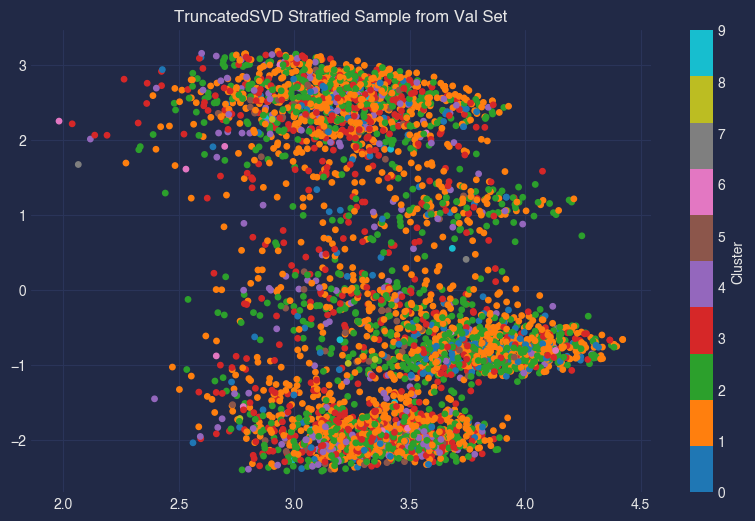

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD

X_sample, _, y_sample, _ = train_test_split(
    df_guide_encoded,
    df_guide['CLUSTER_BIN'],
    train_size=0.01,
    stratify=df_guide['CLUSTER_BIN'])
#2d
svd_2d = TruncatedSVD(n_components=2)
X_2d = svd_2d.fit_transform(X_sample)

plt.figure(figsize=(10, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_sample.astype('category').cat.codes, cmap='tab10', alpha=1.0, s=15)
plt.title('TruncatedSVD Stratfied Sample from Val Set')
plt.grid(True)
plt.colorbar(label='Cluster')
plt.show()

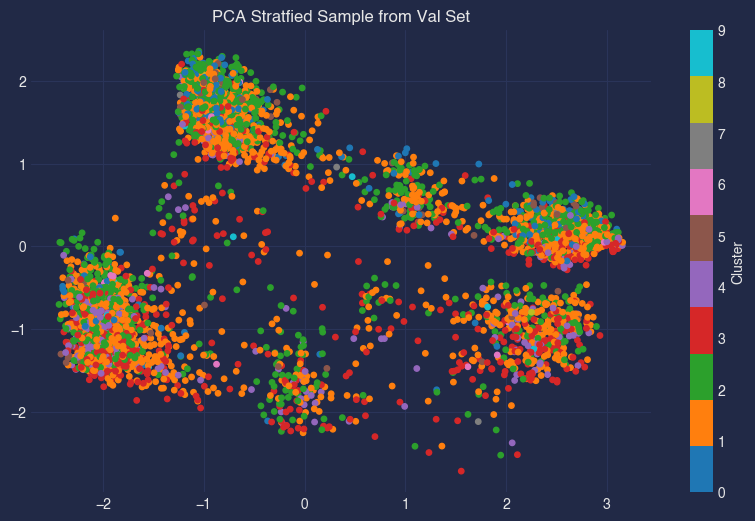

In [39]:
from sklearn.decomposition import PCA

#for redundancy reduction
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_sample)

plt.figure(figsize=(10, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_sample.astype('category').cat.codes, cmap='tab10', alpha=1.0, s=15)
plt.title('PCA Stratfied Sample from Val Set')
plt.grid(True)
plt.colorbar(label='Cluster')
plt.show()

In [40]:
import prince

y = df_guide['CLUSTER_BIN']
X = df_guide.drop(columns=['CLUSTER_BIN']).copy()
X = X.astype(str)
X_sample, _, y_sample, _ = train_test_split(
    X,
    y,
    train_size=0.01,   
    stratify=y)

#MCA 2D
mca = prince.MCA(
    n_components=2,
    n_iter=10)

X_mca = mca.fit_transform(X_sample)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_mca[0],
    X_mca[1],
    c=y_cat.codes,
    cmap='tab10',
    s=15)

plt.title('MCA Stratfied Sample from Val Set')
plt.grid(True)
handles, _ = scatter.legend_elements()
plt.legend(handles, y_cat.categories, title='Cluster')

plt.show()

NameError: name 'y_cat' is not defined

<Figure size 1000x600 with 0 Axes>

As it can be seen, there does not seem to exist an obvious underlying structure. We can clearly see that some labels are more dominant in frequence over others and, in some projections, it is possible to identify sorts of shapes. However, those do not match a specifc diagnostic category.  

## Exploratory Analysis

We will perform an initial exploratory data analysis (EDA) to understand the distribution of the features.

In [ ]:
#visualizing the distribution of each feature
def plot_distribution(df):
    print("\nUnivariate Analysis: Feature Distributions")
    cat_columns = df.select_dtypes(include=['object', 'category']).columns
    num_columns = df.select_dtypes(include=['int8', 'int64', 'float64']).columns

    #categorical distribution
    for col in cat_columns:
        plt.figure(figsize=(8, 6))
        sns.countplot(x=col, data=df, palette='blues')
        plt.title(f'Distribution of {col}')
        plt.xticks(rotation=45)
        plt.show()

    #numerical features distribution
    for col in num_columns:
        plt.figure(figsize=(8, 6))
        sns.histplot(df[col], kde=False, bins=10, color="skyblue")
        plt.title(f'Distribution of {col}')
        plt.show()

plot_distribution(df)

## Model Experimentation

Clustering algorithms can be theoretically divided into several families, based on their assumptions, splitting strategies, and other factors. One such division is:

**Partition-based algorithms** aim to divide the dataset into distinct groups, typically through iterative optimization methods. The most common example is the k-means algorithm, which seeks to minimize the within-cluster variance.

**Hierarchical clustering algorithms** build a tree-like structure (dendrogram) to represent the nested groupings of data. These algorithms can be divided into agglomerative (bottom-up) or divisive (top-down) approaches, such as agglomerative hierarchical clustering.

**Density-based algorithms**, like DBSCAN, group data points that are closely packed together, while marking points in low-density regions as outliers. Works particularly well when clusters are of arbitrary shapes.

**Grid-based algorithms** divide the data space into a finite number of cells and perform clustering on the grid structure, such as STING (Statistical Information Grid).

**Model-based algorithms** assume that data is generated by a combination of underlying probability distributions, such as in the Gaussian Mixture Model (GMM).

In the following cells, we will explore one representative algorithm from each family to understand the assumptions they make about the data and how their different approaches might affect clustering outcomes. This will help us identify which algorithm is most appropriate for different types of datasets and clustering tasks.

In [ ]:
df_sampled = df_encoded.sample(frac=0.5, random_state=55)

## Partition-based algorithms: K-Means

It starts with a set of points as centroids, each representing a cluster. It classifies other points as belonging to the cluster which they're closer to the centroid. Then, it calculates newer centroids, based solely on each cluster's points. And re-does the process, updating labels as needed. It stops when convergence is reached.

In [43]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, v_measure_score

### Model Training & Evaluation

We will now implement the K-Means clustering algorithm using scikit-learn. To determine the optimal number of clusters, we'll utilize the Elbow Method and the Silhouette Score.

In [44]:
#Evaluate K-Means with different values of k using the silhouette score as an insight into the potential performance of the method (since we know k=10 from df_guide)
#to begin with, we're going with usual euclidean distance, but since our features are all categorical encoded in numerical types, other distance metrics, such as Jaccard, are more appropriate
silhouette_scores = []
range_k = range(2, 15) 

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_sampled)
    score = silhouette_score(df_sampled, kmeans.labels_)
    silhouette_scores.append(score)

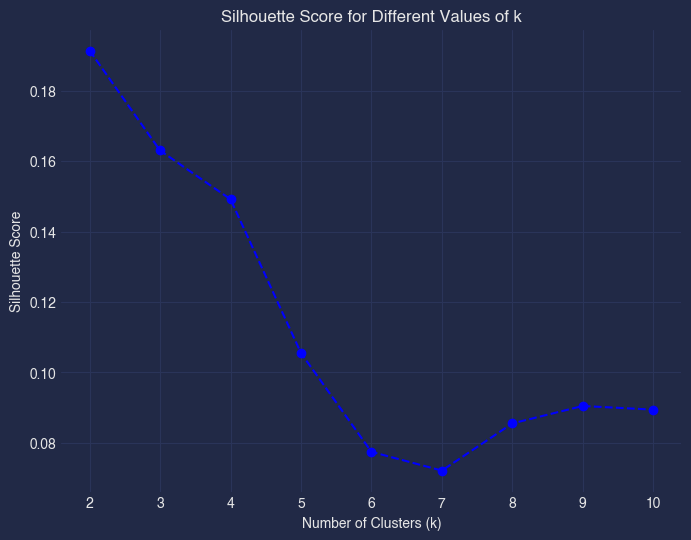

In [45]:
#plot silhouette scores to determine the best k
plt.figure(figsize=(8, 6))
plt.plot(range_k, silhouette_scores, marker='o', color='b', linestyle='--')
plt.title("Silhouette Score for Different Values of k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range_k)
plt.grid(True)
plt.show()

This suggests clearly that 7 clusters exist, which seems interesting since we know beforehand that we are working with 10 labels. it may suggest that the structure is not completely clear, or that some sort of sobreposition/mixing may exist. 

Now we will use the determined k with the correct distance metric

In [46]:
def jaccard_distance(X, Y):
    intersection = np.sum(np.minimum(X, Y), axis=1)
    union = np.sum(np.maximum(X, Y), axis=1)
    return 1 - intersection / (union + 1e-10)

In [47]:
def custom_kmeans(df, k, centroids, max_iter=100, tol=1e-4):
    X = df.to_numpy()
    centroids = centroids.to_numpy() if hasattr(centroids, "to_numpy") else np.asarray(centroids)
    #basic kmeans algorithm
    for i in range(max_iter):
        #compute jacard distance
        distances = np.array([jaccard_distance(X, centroid) for centroid in centroids])  
        #assigns cluster
        labels = np.argmin(distances, axis=0)
        #update centroids
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        #stop checking
        if np.all(np.abs(new_centroids - centroids) < tol):
            break
        centroids = new_centroids
    
    return labels

In [48]:
k = 7 #using the best kk found before
n_samples = df_sampled.shape[0]
random_indices = np.random.choice(n_samples, k, replace=False)
centroids = df_sampled.iloc[random_indices]
labels = custom_kmeans(df_sampled, k, centroids)
#df_sampled['Kmeans_custer'] = labels

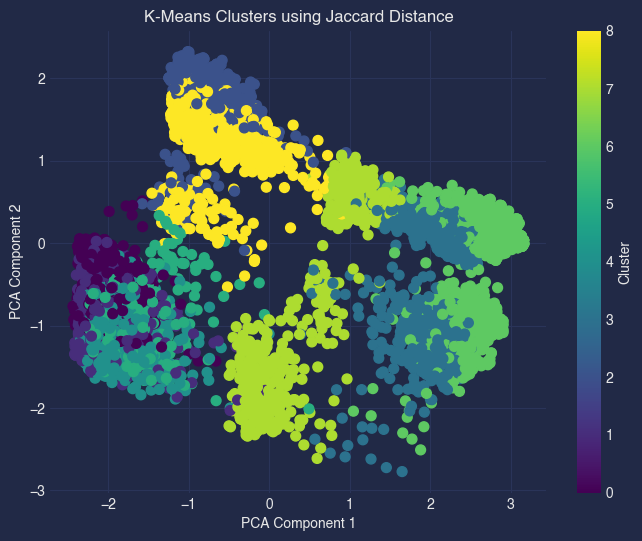

In [49]:
df_pca = pca_space.transform(df_sampled)

plt.figure(figsize=(8, 6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels, cmap='viridis', s=50)
plt.title('K-Means Clusters using Jaccard Distance')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

Let's now take a look at the projection of the labeled data in the same pca space. Let's check if there's any resamblance at all between the data's real organization and the algorithm's output.

In [51]:
rng = np.random.default_rng(42)  
n = len(df_pca)
idx = rng.choice(n, size=int(n * 0.2), replace=False)

df_pca_sample = df_pca[idx]
y_sample = y[idx]   

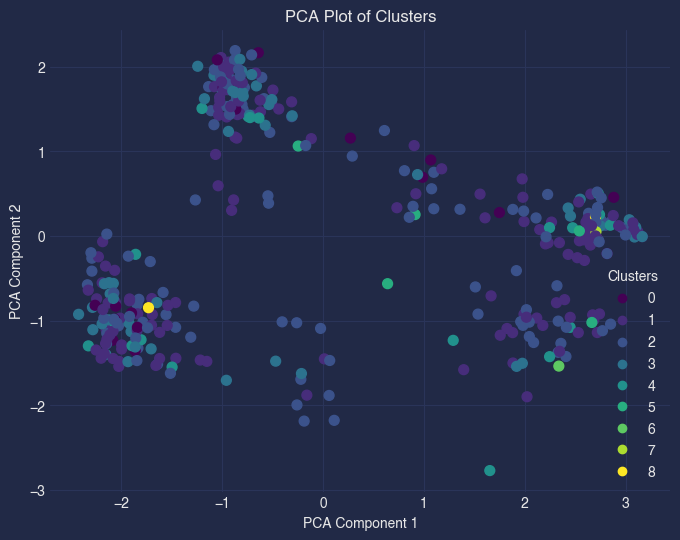

In [52]:
df_pca = pca_space.transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_pca_sample[:, 0],
    df_pca_sample[:, 1],
    c=y_sample,
    cmap='viridis',
    s=50)
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.title('PCA Plot of Clusters - validation set')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In the following lines we experiment two variations: kmodes on not ohe data, and minibatchkeans on oncoded features normalized by the number of categories. The reason for the first is because, as sickit's documentation explains, it is a more natural feature for the type of data we're dealing with. The reason for the second is that, when applying a "custom" kmeans as we did, runtime increases, as we did not implement any optimizations that exist in open libraries. Thus, we "normalize" the features, as if weighting them, to avoid that features with many categories dominate over others in distance calculations and apply a batch version of the algorithm. However, we did not achieve good results with neither. 

In [ ]:
from kmodes.kmodes import KModes

k = 10  

km = KModes(
    n_clusters=k,
    init='Huang',    
    n_init=10,
    verbose=1,
    random_state=42)

labels_kmodes = km.fit_predict(df)

Init: initializing centroids


In [37]:
from sklearn.cluster import MiniBatchKMeans

original_cols = list(df.columns)
encoded_cols = list(df_encoded.columns)
col_to_feature = {}

sorted_original_cols = sorted(original_cols, key=len, reverse=True)
for enc_col in encoded_cols:
    matched = None
    for orig_col in sorted_original_cols:
        if enc_col.startswith(orig_col + "_"):
            matched = orig_col
            break
    if matched is None:
        raise ValueError(
            f"fck'{enc_col}' "
            f"bro."
        )  
    col_to_feature[enc_col] = matched


feature_ncats = pd.Series(col_to_feature).value_counts().to_dict()

#norm by 1 / sqrt(n cats)
weights_vector = np.array(
    [1.0 / np.sqrt(feature_ncats[col_to_feature[col]]) for col in encoded_cols],
    dtype=np.float32)
X = df_encoded.to_numpy(dtype=np.float32)
X_weighted = X * weights_vector

k = 10
kmeans = MiniBatchKMeans(
    n_clusters=k,
    random_state=42,
    batch_size=2048,
    n_init=10,
    max_iter=100)

labels_mbkmeans = kmeans.fit_predict(X_weighted)

In [38]:
submission = pd.DataFrame({
    "ID": range(len(labels_mbkmeans)),
    "CLUSTER": labels_mbkmeans})

submission.to_csv("clusters_mbkmeans.csv", index=False)

### Discussion
As it was (very) expected by the visualization results, the clustering obtained with k-means performed very poorly. Even when using k=10, which was the previously known number of clusters, the results obtained seemed almost random in comparison to our labeled sample. This might indicate that either the algorithm learnt another notion of similarity, another idea of closeness other than the one implied by the labels, or that it did, in fact, learn false patterns. On the former is the fact, as shown in the pca, we found pretty reasonably looking clusters. On the latter, is the rather low sillhouette score obtained when fitting it to the labeled data (~0.1149). 
From here, we might take the chance to generalize and assume that other partition-based algorithms would perform just as poorly. That given, we won't waste time tuning any hiperparameters or doing any other adjustments. 

## Hierarchical clustering algorithms: Complete Linkage

In general, this family of algorithms consist in stablishing a splitting line in a "tree" called dendogram. We can either start each point as being its own cluster and merge together the most similar clusters until there's only one large cluster (bottom up strategy) or begin with a single huge cluster and successively split it until we end up with clusters formed by only one example each. Those are lazy algorithms and they're quite expensive computationally. Given that our dataset is quite huge, it may not be the best fit. On top of that, we have as prior info the number existing of clusters, which makes it an even less appropriate technique. Still, for demonstration and completeness purposes only, we're doing a simple run of it.

### Model Training & Evaluation

In [55]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, dendrogram

In [56]:
k = 10  #do val
df_sampled_bool = df_sampled.to_numpy(dtype=bool)

#jaccard dist matrix
jaccard_dist = pairwise_distances(df_sampled_bool, metric='jaccard')
#complete linkage hierarchical clustering 
hierarchical_model = AgglomerativeClustering(
    n_clusters=k,
    metric='precomputed',
    linkage='complete')

labels_hierarchical = hierarchical_model.fit_predict(jaccard_dist)

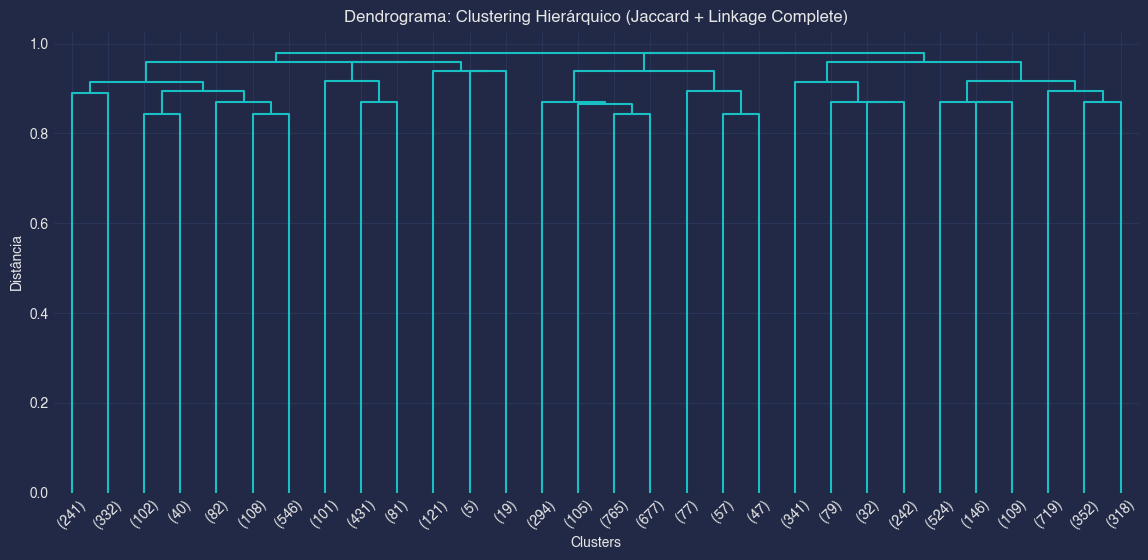

In [57]:
Z = linkage(df_sampled_bool, method='complete', metric='jaccard')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Dendrograma: Clustering Hierárquico (Jaccard + Linkage Complete)')
plt.xlabel('Clusters')
plt.ylabel('Distância')
plt.show()

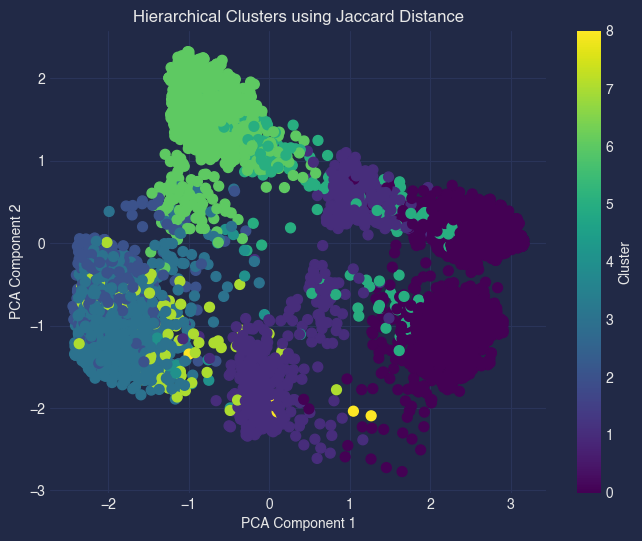

In [58]:
df_pca = pca_space.transform(df_sampled)

plt.figure(figsize=(8, 6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels_hierarchical, cmap='viridis', s=50)
plt.title('Hierarchical Clusters using Jaccard Distance')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [61]:
ari = adjusted_rand_score(y, y_labels)
ami = adjusted_mutual_info_score(y, y_labels)
v   = v_measure_score(y, y_labels)

print("ARI:", ari)
print("AMI:", ami)
print("V-measure:", v)

ARI: 0.004160263755200992
AMI: 0.020624258371025262
V-measure: 0.020675392804513797


### Discussion

Even though the clusters in the pca projection don't look bad, quantitative evaluation metrics showed that, in fact, the model did not perform well. Thus, we'll move on.

## Grid-based algorithms: CLIQUE

With one-hot encoded datasets as this, we often end up with a very sparse, high-dimensional, axis-aligned space, which is usually a bad match for this kind of gridding (even though, computationally, it scales linearly). Still, just as Hierarchical techniques, we'll reproduce it here for the sake of illustration. The basic ideia is: it starts from a lower dimensional subspace, partitions it into cells and associates each with a density estimate (fraction of points belonging to it/total number of points). A cell is considered dense if it achieves a minimal value. It then merges together neighbouring dense cells into the same cluster. In this sense, it could also be argued that it fit as a density algorithm as well. The overall ideia holds progressively for higher dimensions. It is relevant, however, to mention a significative drawback: it assumes the columns are independent, which is known to not be completely true for one-hot encodings as ours. Still, it is worth a try.

### Model Training & Evaluation


In [62]:
from pyclustering.cluster.clique import clique

In [ ]:
df_sampled_bool = df_sampled.to_numpy(dtype=float)
data = df_sampled_bool .tolist()

clique_instance = clique(
    data=data,
    amount_intervals=0.2,
    density_threshold=0.5,
    ccore=False)

clique_instance.process()
clusters = clique_instance.get_clusters()
noise = clique_instance.get_noise()
labels = np.full(X.shape[0], -1, dtype=int)

for cluster_id, cluster_points in enumerate(clusters):
    labels[cluster_points] = cluster_id

print("Number of clusters:", len(clusters))
print("Noise points:", len(noise))
print(pd.Series(labels).value_counts().sort_index())

In [ ]:
mask = labels != -1

if len(set(labels[mask])) >= 2:
    sil = silhouette_score(X[mask], labels[mask], metric="jaccard")
    print("Silhouette:", sil)
else:
    print("Silhouette deu errado S2")

In [ ]:
df_pca = pca_space.transform(df_sampled)

plt.figure(figsize=(8, 6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels, cmap='viridis', s=50)
plt.title('CLIQUE Clusters (complete)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
cluster_labeled = labels[mask_labeled]
ari = adjusted_rand_score(y, y_labels)
ami = adjusted_mutual_info_score(y, y_labels)
v = v_measure_score(y, y_labels)

print("ARI:", ari)
print("AMI:", ami)
print("V-measure:", v)

### Discussion

We did not notice any outstanding performance. We would still prefer to try out other options

## Model-based algorithms: Bernoulli Mixture Model

This family of models is based on the assumption that each cluster represents a different statistical population, each with its own probability distribution and parameters. It tries to find the combination of probability distributions that make the observed data more likely. One of the most known algorithms is GMM, or gaussian mixture models, which hypothetesis that the observed data come from a set of normal distributions. As our data is essentially categorical, more adequate fits'd be algorithms for discrete or binary distributions. That's why we chose a method based on Bernoulli distributions.

### Model Training & Evaluation


In [47]:
!pip3 install pomegranate

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for apricot-select: filename=apricot_select-0.6.1-py3-none-any.whl size=48800 sha256=d84b1a8b98fee9ee2058800e862eb97ccdfb773c5a2b699f8feed96fdea875a2
  Stored in directory: /Users/llbm/Library/Caches/pip/wheels/d0/cb/ce/ea53ad7d1e794951758d59054880637b39079cd40ada71ce59
Successfully built apricot-select
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pomegranate]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [48]:
from pomegranate.gmm import GeneralMixtureModel
from pomegranate.distributions import Bernoulli

In [49]:
k = 18 
df_sampled_bool = df_sampled.to_numpy(dtype=np.int8)
df_encoded_bool = df_encoded.to_numpy(dtype=np.int8)

components = [Bernoulli() for _ in range(k)]

bernoulli_mix = GeneralMixtureModel(
    distributions=components,
    max_iter=28,
    tol=0.01,
    random_state=31,
    verbose=True)
bernoulli_mix.fit(df_sampled_bool)

#rótulos hard
labels_bernoulli = bernoulli_mix.predict(df_encoded_bool)
print(labels_bernoulli)

[1] Improvement: nan, Time: 84.75s
[2] Improvement: nan, Time: 74.2s
[3] Improvement: nan, Time: 74.78s
[4] Improvement: nan, Time: 74.1s
[5] Improvement: nan, Time: 78.49s
[6] Improvement: nan, Time: 78.99s
[7] Improvement: nan, Time: 76.58s
[8] Improvement: nan, Time: 79.78s
[9] Improvement: nan, Time: 78.1s
[10] Improvement: nan, Time: 82.95s
[11] Improvement: nan, Time: 79.1s
[12] Improvement: nan, Time: 77.16s
[13] Improvement: nan, Time: 78.43s
[14] Improvement: nan, Time: 77.76s
[15] Improvement: nan, Time: 80.1s
[16] Improvement: nan, Time: 77.82s
[17] Improvement: nan, Time: 75.92s
[18] Improvement: nan, Time: 78.54s
[19] Improvement: nan, Time: 79.6s
[20] Improvement: nan, Time: 81.59s
[21] Improvement: nan, Time: 80.57s
[22] Improvement: nan, Time: 83.04s
[23] Improvement: nan, Time: 79.75s
[24] Improvement: nan, Time: 82.74s
[25] Improvement: nan, Time: 80.1s
[26] Improvement: nan, Time: 80.98s
[27] Improvement: nan, Time: 79.92s
tensor([0, 0, 0,  ..., 0, 0, 0])


In [51]:
submission = pd.DataFrame({
    "ID": range(len(labels_bernoulli)),
    "CLUSTER": labels_bernoulli})

submission.to_csv("clusters_bernoulli_v3.csv", index=False)


## Discussion


Here we obtained a very interesting initial performance. In a way, this is explainable. As we could see in the visualizations, the data didn't seem to have a typical cluster organization. In fact, there didn't seem to be any specific shapes or set locations, and there was significant overlap. That is, there were indications that perhaps our data were not geometrically separable (at least not in lower dimensions). This family, however, tries probabilistically separability. The good performance of the algorithm points in that direction. This seemed to be the best strategy so far, so it's worth tuning hyperparameters and experimenting with other algorithms in the family.

## Density-based algorithms: DBSCAN

In general terms, this algorithms splits points into three groups: core, border and outlier. It starts with a random point. If there exists a minimum amount of other points in a certain radius from it, it is considered core. Then it goes looking into all those reachable points, doing the same process. If, however, there's less than a minima reachable from it, it is direcly considered border. Last, if there are points left, which are not reachable from other border or core points, and that do not have a minima amount of others close by, those are considered outliers. 

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import pairwise_distances

### Model Training & Evaluation

It turns out that even with a very small sample, the algorithm did take a long time to run. Given the dimension of our training set, it is clear that dbscan's out of our possibilities pool

In [ ]:
# array = df_sampled.to_numpy(dtype=bool)
# D = pairwise_distances(array, metric="jaccard")
# # DBSCAN
# dbscan = DBSCAN(
#     eps=0.8,         #basic
#     min_samples=4,    #we not tunning now
#     metric="precomputed")

# labels = dbscan.fit_predict(D)

# print("Clusters encontrados:", len(set(labels)) - (1 if -1 in labels else 0))
# print("Pontos classificados como ruído:", np.sum(labels == -1))
# print(pd.Series(labels).value_counts().sort_index())

In [ ]:
# df_pca = pca_space.transform(df_sampled)

# plt.figure(figsize=(8, 6))
# plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels, cmap='viridis', s=50)
# plt.title('K-Means Clusters using Jaccard Distance')
# plt.xlabel('PCA Component 1')
# plt.ylabel('PCA Component 2')
# plt.colorbar(label='Cluster')
# plt.show()

In [ ]:
# #applying it only to the validation set so we can have quantitative insights into the performance
# D = pairwise_distances(X, metric="jaccard")
# # DBSCAN
# dbscan = DBSCAN(
#     eps=0.30,         #basic
#     min_samples=5,    #we not tunning now
#     metric="precomputed")

# labels = dbscan.fit_predict(D)

# print("Clusters encontrados:", len(set(labels)) - (1 if -1 in labels else 0))
# print("Pontos classificados como ruído:", np.sum(labels == -1))
# print(pd.Series(labels).value_counts().sort_index())

In [ ]:
# df_pca = pca_space.transform(X)

# plt.figure(figsize=(8, 6))
# scatter = plt.scatter(
#     df_pca_sample[:, 0],
#     df_pca_sample[:, 1],
#     c=y_sample,
#     cmap='viridis',
#     s=50
# )
# plt.legend(*scatter.legend_elements(), title="Clusters")
# plt.title('PCA Plot of Clusters')
# plt.xlabel('PCA Component 1')
# plt.ylabel('PCA Component 2')
# plt.show()

In [ ]:
# score = silhouette_score(df_sampled, labels, metric="jaccard")
# print(score)

In [ ]:
# ari = adjusted_rand_score(y, y_labels)
# ami = adjusted_mutual_info_score(y, y_labels)
# v = v_measure_score(y, y_labels)

# print("ARI:", ari)
# print("AMI:", ami)
# print("V-measure:", v)

## Semi-Supervised Strategies

So far, we tried only traditional non supervised techniques, even though we had a validation set (labeled) available. We simply used the latter for qualitative comparisons. As seen, we did not achieve significant potential with most of the models. Because of that, we looked for semi-supervised learning techniques, which consist in clustering algorithms that take into consideration the known labels. In the following cells, we will experiment with a few of those and see if we achieve better results. 

## Seeded K-means 

This algorithm is basically the K-means algorithm, except that labeled data is used to initialize the centroids. 

In [52]:
k = 10 
label_cols = [f'CLUSTER_BIN_{i}' for i in range(k)]

#split labels and features
#since our sample is rather small, there shoudln't be no memory issues using .copy here
guide_features = df_guide_encoded.drop(columns=label_cols).copy()
guide_labels_onehot = df_guide_encoded[label_cols].copy()
guide_features = guide_features[df_sampled.columns]
#from onehot to labels
guide_labels = guide_labels_onehot.idxmax(axis=1)

In [53]:
#centroids from labels
centroids_list = []
for col in label_cols:
    cluster_points = guide_features[guide_labels == col] 
    if len(cluster_points) == 0:
        raise ValueError(f"")
    else:
        centroid = cluster_points.mean(axis=0)
        centroids_list.append(centroid)

centroids = pd.DataFrame(centroids_list)
centroids.columns = df_sampled.columns

#we'll use the same k-means with jaccard distance
labels_seededkmeans = custom_kmeans(df_sampled, k, centroids)

print(pd.Series(labels_seededkmeans).value_counts().sort_index())

0    646359
1    712674
2    186092
3    230437
4    165128
5    170889
6    369892
7    655387
8    409476
Name: count, dtype: int64


In [54]:
submission = pd.DataFrame({
    "ID": range(len(labels_seededkmeans)),
    "CLUSTER": labels_seededkmeans})

submission.to_csv("clusters_seededkmeans.csv", index=False)


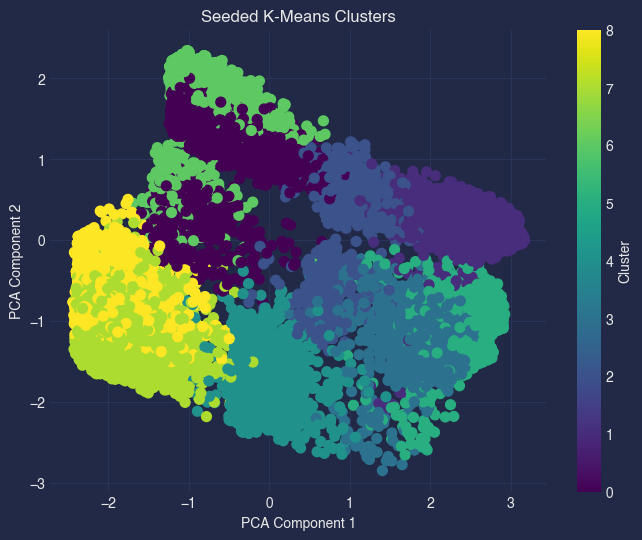

In [49]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, adjusted_mutual_info_score, v_measure_score
import matplotlib.pyplot as plt

df_pca = pca_space.transform(df_sampled)

plt.figure(figsize=(8, 6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels_seededkmeans, cmap='viridis', s=50)
plt.title('Seeded K-Means Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [50]:
#intern eval
score = silhouette_score(df_sampled, labels_seededkmeans, metric="jaccard")
print("Silhouette:", score)

Silhouette: 0.12861961879964634


## Neighborhood Components Analysis (NCA) + LR

In this strategy, we first map the examples to a new space in a way that ones belonging to the same cluster lie closer together than ones from distinct clusters. Then, we apply a sypervised strategy to the vectors in this latent space (at first, we hopped to apply knn, but the database's size was prohibiting, so we changed it for a regression i.e not lazy technique). We had his idea from the visual inspection of the clusters: it did not seem to exist a clear, geometrical division at all in the projection space. Thus, we wanted to "make labeling's life easier" by mapping the registers to a dimensional space that provided better cluster separation.

In [41]:
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [42]:
label_cols = sorted([c for c in df_guide_encoded.columns if c.startswith("CLUSTER_BIN_")])
print(label_cols)

['CLUSTER_BIN_0', 'CLUSTER_BIN_1', 'CLUSTER_BIN_2', 'CLUSTER_BIN_3', 'CLUSTER_BIN_4', 'CLUSTER_BIN_5', 'CLUSTER_BIN_6', 'CLUSTER_BIN_7', 'CLUSTER_BIN_8', 'CLUSTER_BIN_9']


In [43]:
X_guide = df_guide_encoded.drop(columns=label_cols).copy()
y_guide_onehot = df_guide_encoded[label_cols].copy()

# one-hot -> label enc
y_guide = y_guide_onehot.idxmax(axis=1)
X_guide = X_guide.sample(frac=0.05, random_state=42)
y_guide = y_guide.loc[X_guide.index]
X_df = df_encoded.copy()

In [44]:
missing_in_df = set(X_guide.columns) - set(X_df.columns)
extra_in_df = set(X_df.columns) - set(X_guide.columns)

if missing_in_df:
    raise ValueError(f"Missing columns in df_encoded: {missing_in_df}")

if extra_in_df:
    print(f"Extra columns in df_encoded will be ignored: {extra_in_df}")



In [45]:
X_df = X_df[X_guide.columns]

In [46]:
pipeline_nca_lr = Pipeline([
    ("nca", NeighborhoodComponentsAnalysis(
        n_components=min(20, X_guide.shape[1]),
        random_state=76,
        max_iter=300
    )),
    ("lr", LogisticRegression(
        max_iter=1000, 
        class_weight="balanced"
    ))])

In [ ]:
#train
pipeline_nca_lr.fit(X_guide, y_guide)

In [ ]:
y_val_pred = pipeline_nca_lr.predict(X_df)


In [ ]:
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# label columns in the labeled encoded dataset
label_cols = sorted([c for c in df_guide_encoded.columns if c.startswith("CLUSTER_BIN_")])
print(label_cols)

# labeled guide set
X_guide = df_guide_encoded.drop(columns=label_cols).copy()
y_guide_onehot = df_guide_encoded[label_cols].copy()

# convert one-hot labels back to single label
y_guide = y_guide_onehot.idxmax(axis=1)

# unlabeled full dataset to receive predictions
X_df = df_encoded.copy()

# make sure columns match exactly
missing_in_df = set(X_guide.columns) - set(X_df.columns)
extra_in_df = set(X_df.columns) - set(X_guide.columns)

if missing_in_df:
    raise ValueError(f"Missing columns in df_encoded: {missing_in_df}")

if extra_in_df:
    print(f"Extra columns in df_encoded will be ignored: {extra_in_df}")

X_df = X_df[X_guide.columns]

# train supervised metric-learning + classifier on guide data
pipeline_nca_lr = Pipeline([
    ("nca", NeighborhoodComponentsAnalysis(
        n_components=min(20, X_guide.shape[1]),
        random_state=42,
        max_iter=300
    )),
    ("lr", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

pipeline_nca_lr.fit(X_guide, y_guide)

# predict labels for the full unlabeled dataset
labels_nca_lr = pipeline_nca_lr.predict(X_df)

print(labels_nca_lr)

['CLUSTER_BIN_0', 'CLUSTER_BIN_1', 'CLUSTER_BIN_2', 'CLUSTER_BIN_3', 'CLUSTER_BIN_4', 'CLUSTER_BIN_5', 'CLUSTER_BIN_6', 'CLUSTER_BIN_7', 'CLUSTER_BIN_8', 'CLUSTER_BIN_9']


## Conclusion

In this project, we applied clustering algorithms to perform database segmentation. Through exploratory analysis, data preprocessing, model fitting and evaluation, we tried to identify distinct "groups of outcomes".